# 3. Logistic Regression and Random Forest Baselines

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

import joblib

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 1000)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported successfully.")

Libraries imported successfully.


## 3.1 Load Train, Validation, and Test Splits

In [2]:
PROJECT_DIR = Path.cwd().resolve()

if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

split_dir = PROJECT_DIR / "data" / "processed" / "tabular_splits"

X_train = pd.read_csv(split_dir / "X_train.csv")
X_val = pd.read_csv(split_dir / "X_val.csv")
X_test = pd.read_csv(split_dir / "X_test.csv")

y_train = pd.read_csv(split_dir / "y_train.csv").squeeze("columns")
y_val = pd.read_csv(split_dir / "y_val.csv").squeeze("columns")
y_test = pd.read_csv(split_dir / "y_test.csv").squeeze("columns")

print("Data loaded successfully.\n")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

Data loaded successfully.

X_train: (27938, 165)
X_val: (9313, 165)
X_test: (9313, 165)
y_train: (27938,)
y_val: (9313,)
y_test: (9313,)


In [3]:
def print_class_distribution(name, y):
    counts = y.value_counts().sort_index()
    percentages = y.value_counts(normalize=True).sort_index() * 100
    print(f"{name} distribution:")
    print(counts)
    print(percentages.round(2))
    print("-" * 40)

print_class_distribution("Train", y_train)
print_class_distribution("Validation", y_val)
print_class_distribution("Test", y_test)

Train distribution:
label
0    25211
1     2727
Name: count, dtype: int64
label
0    90.24
1     9.76
Name: proportion, dtype: float64
----------------------------------------
Validation distribution:
label
0    8404
1     909
Name: count, dtype: int64
label
0    90.24
1     9.76
Name: proportion, dtype: float64
----------------------------------------
Test distribution:
label
0    8404
1     909
Name: count, dtype: int64
label
0    90.24
1     9.76
Name: proportion, dtype: float64
----------------------------------------


## 3.2 Feature Scaling for Logistic Regression

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed for Logistic Regression.")
print("Scaled train shape:", X_train_scaled.shape)

Feature scaling completed for Logistic Regression.
Scaled train shape: (27938, 165)


## 3.3 Helper Functions for Evaluation

In [5]:
def evaluate_model(model_name, y_true, y_pred, y_proba):
    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba)
    }
    return metrics

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Predicted Licit", "Predicted Illicit"],
                yticklabels=["Actual Licit", "Actual Illicit"])
    plt.title(title)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

def plot_roc_curve(y_true, y_proba, title):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label="ROC Curve")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_pr_curve(y_true, y_proba, title):
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    plt.figure(figsize=(7, 5))
    plt.plot(recall, precision, label="PR Curve")
    plt.title(title)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 3.4 Logistic Regression Baseline

In [6]:
log_reg = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [7]:
log_val_pred = log_reg.predict(X_val_scaled)
log_val_proba = log_reg.predict_proba(X_val_scaled)[:, 1]

log_val_metrics = evaluate_model("Logistic Regression - Validation", y_val, log_val_pred, log_val_proba)
pd.DataFrame([log_val_metrics])

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Logistic Regression - Validation,0.876839,0.438278,0.929593,0.5957,0.965702,0.749477


Logistic Regression - Validation Classification Report:

              precision    recall  f1-score   support

           0     0.9913    0.8711    0.9274      8404
           1     0.4383    0.9296    0.5957       909

    accuracy                         0.8768      9313
   macro avg     0.7148    0.9004    0.7615      9313
weighted avg     0.9374    0.8768    0.8950      9313



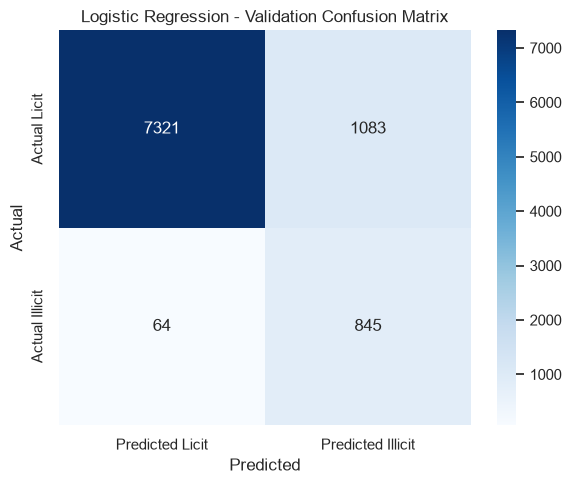

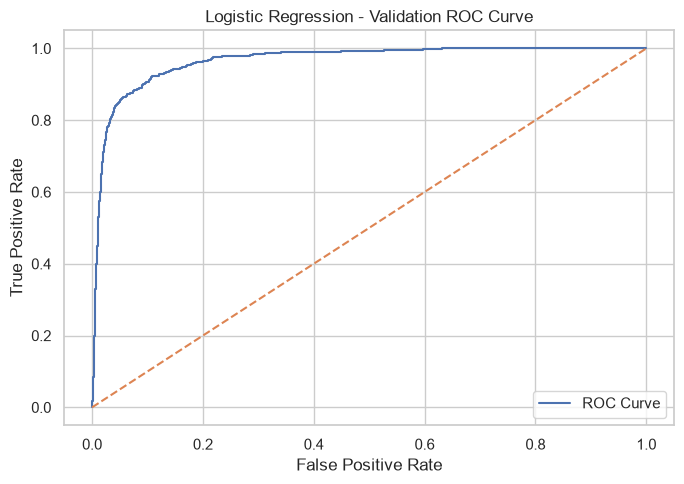

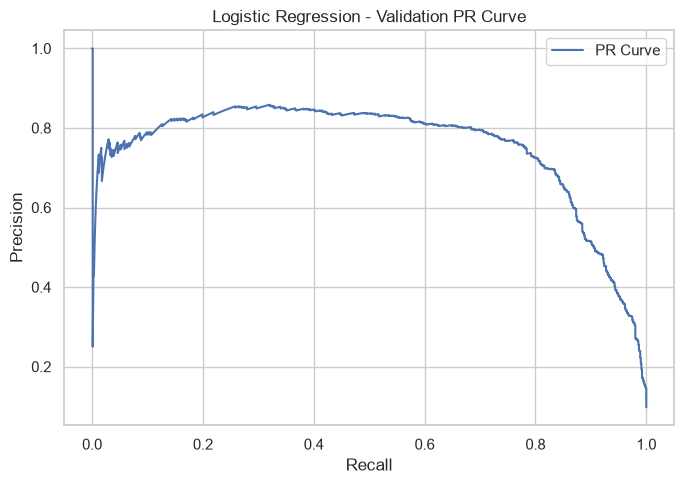

In [8]:
print("Logistic Regression - Validation Classification Report:\n")
print(classification_report(y_val, log_val_pred, digits=4))

plot_confusion_matrix(y_val, log_val_pred, "Logistic Regression - Validation Confusion Matrix")
plot_roc_curve(y_val, log_val_proba, "Logistic Regression - Validation ROC Curve")
plot_pr_curve(y_val, log_val_proba, "Logistic Regression - Validation PR Curve")

The Logistic Regression baseline provides a useful reference point for later models. Because it is a linear model, its performance gives an indication of how much predictive information can be captured without more flexible non-linear or graph-based methods.

## 3.5 Random Forest Baseline

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [10]:
rf_val_pred = rf_model.predict(X_val)
rf_val_proba = rf_model.predict_proba(X_val)[:, 1]

rf_val_metrics = evaluate_model("Random Forest - Validation", y_val, rf_val_pred, rf_val_proba)
pd.DataFrame([rf_val_metrics])

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Random Forest - Validation,0.986256,0.938272,0.919692,0.928889,0.995355,0.975885


Random Forest - Validation Classification Report:

              precision    recall  f1-score   support

           0     0.9913    0.9935    0.9924      8404
           1     0.9383    0.9197    0.9289       909

    accuracy                         0.9863      9313
   macro avg     0.9648    0.9566    0.9606      9313
weighted avg     0.9862    0.9863    0.9862      9313



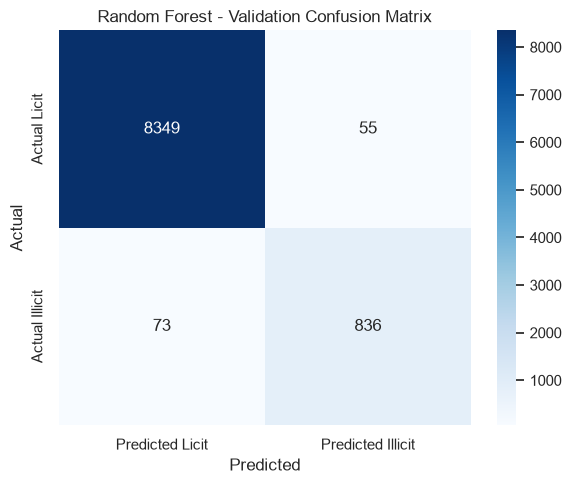

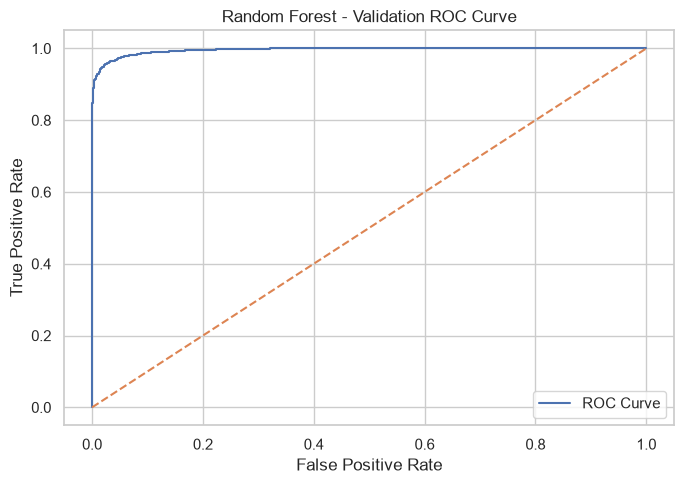

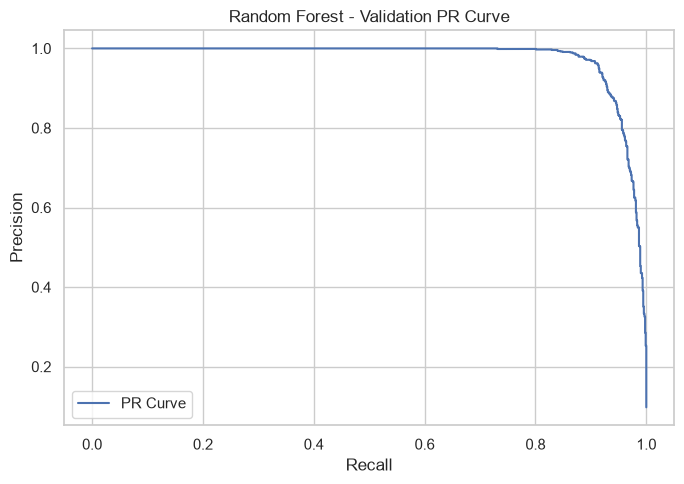

In [11]:
print("Random Forest - Validation Classification Report:\n")
print(classification_report(y_val, rf_val_pred, digits=4))

plot_confusion_matrix(y_val, rf_val_pred, "Random Forest - Validation Confusion Matrix")
plot_roc_curve(y_val, rf_val_proba, "Random Forest - Validation ROC Curve")
plot_pr_curve(y_val, rf_val_proba, "Random Forest - Validation PR Curve")

Random Forest serves as a stronger tabular benchmark because it can model non-linear relationships and interactions among features. Comparing it against Logistic Regression helps establish whether the dataset benefits meaningfully from more flexible tabular learning.

## 3.6 Compare Validation Performance

In [12]:
validation_results_df = pd.DataFrame([log_val_metrics, rf_val_metrics])
display(validation_results_df.sort_values(by="f1_score", ascending=False))

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
1,Random Forest - Validation,0.986256,0.938272,0.919692,0.928889,0.995355,0.975885
0,Logistic Regression - Validation,0.876839,0.438278,0.929593,0.595700,0.965702,0.749477


## 3.7 Final Evaluation on the Test Set

In [13]:
log_test_pred = log_reg.predict(X_test_scaled)
log_test_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

log_test_metrics = evaluate_model("Logistic Regression - Test", y_test, log_test_pred, log_test_proba)
pd.DataFrame([log_test_metrics])

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Logistic Regression - Test,0.877483,0.43952,0.927393,0.596392,0.964486,0.747469


Logistic Regression - Test Classification Report:

              precision    recall  f1-score   support

           0     0.9911    0.8721    0.9278      8404
           1     0.4395    0.9274    0.5964       909

    accuracy                         0.8775      9313
   macro avg     0.7153    0.8997    0.7621      9313
weighted avg     0.9372    0.8775    0.8954      9313



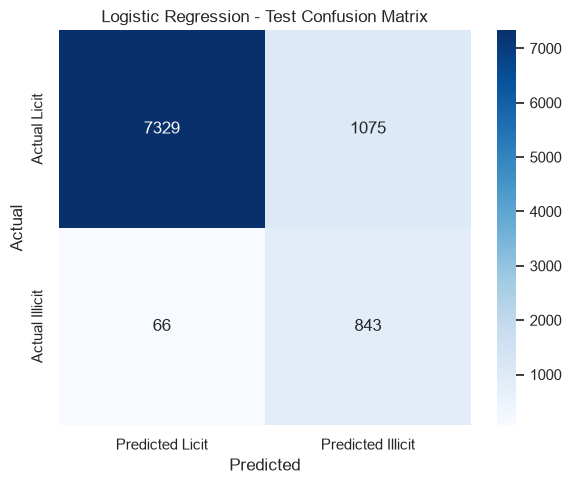

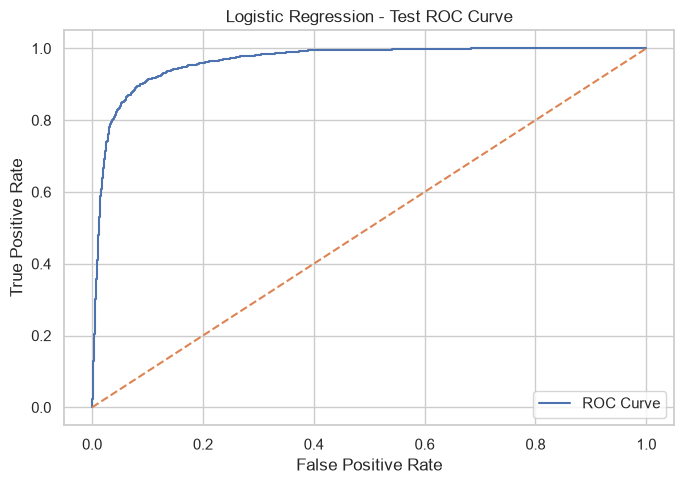

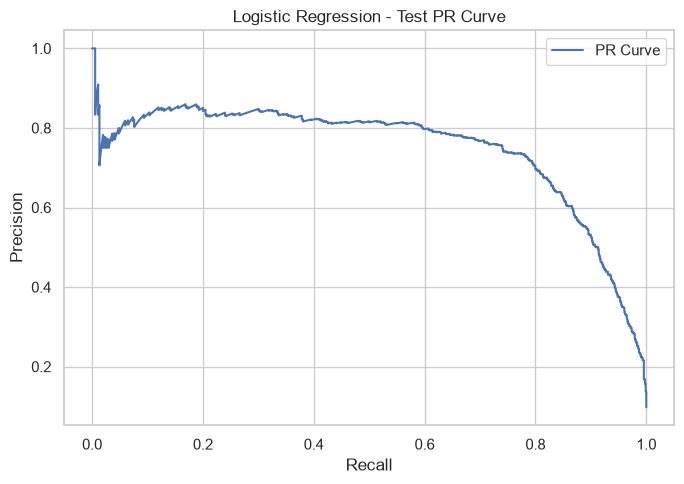

In [14]:
print("Logistic Regression - Test Classification Report:\n")
print(classification_report(y_test, log_test_pred, digits=4))

plot_confusion_matrix(y_test, log_test_pred, "Logistic Regression - Test Confusion Matrix")
plot_roc_curve(y_test, log_test_proba, "Logistic Regression - Test ROC Curve")
plot_pr_curve(y_test, log_test_proba, "Logistic Regression - Test PR Curve")

In [15]:
rf_test_pred = rf_model.predict(X_test)
rf_test_proba = rf_model.predict_proba(X_test)[:, 1]

rf_test_metrics = evaluate_model("Random Forest - Test", y_test, rf_test_pred, rf_test_proba)
pd.DataFrame([rf_test_metrics])

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Random Forest - Test,0.987544,0.952109,0.918592,0.93505,0.99577,0.977396


Random Forest - Test Classification Report:

              precision    recall  f1-score   support

           0     0.9912    0.9950    0.9931      8404
           1     0.9521    0.9186    0.9351       909

    accuracy                         0.9875      9313
   macro avg     0.9717    0.9568    0.9641      9313
weighted avg     0.9874    0.9875    0.9874      9313



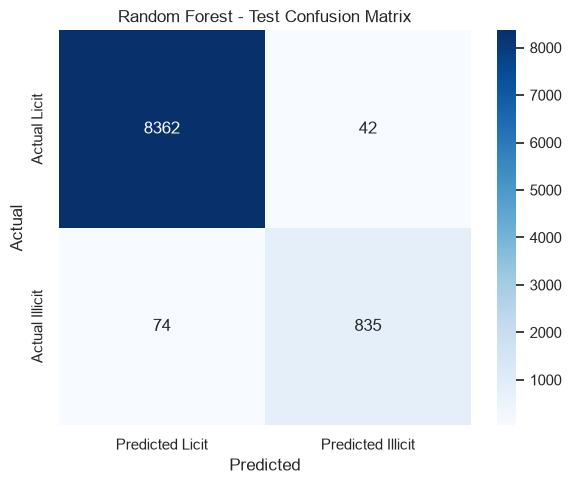

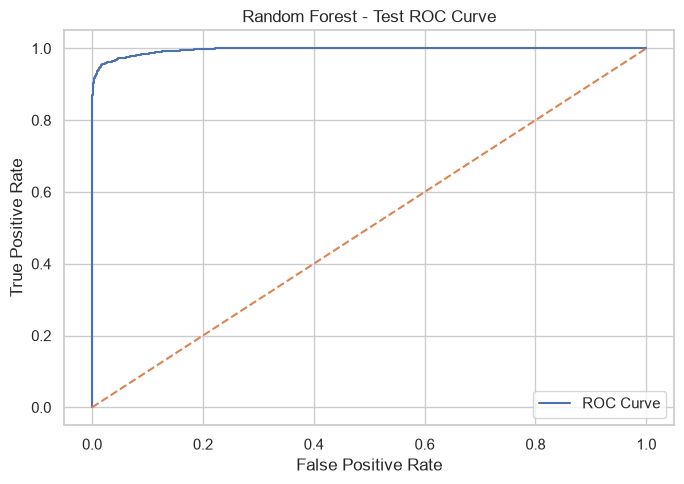

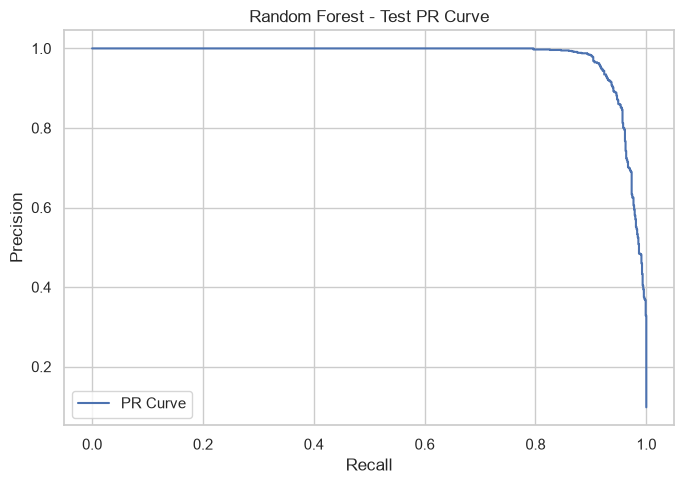

In [16]:
print("Random Forest - Test Classification Report:\n")
print(classification_report(y_test, rf_test_pred, digits=4))

plot_confusion_matrix(y_test, rf_test_pred, "Random Forest - Test Confusion Matrix")
plot_roc_curve(y_test, rf_test_proba, "Random Forest - Test ROC Curve")
plot_pr_curve(y_test, rf_test_proba, "Random Forest - Test PR Curve")

In [17]:
test_results_df = pd.DataFrame([log_test_metrics, rf_test_metrics])
display(test_results_df.sort_values(by="f1_score", ascending=False))

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
1,Random Forest - Test,0.987544,0.952109,0.918592,0.935050,0.995770,0.977396
0,Logistic Regression - Test,0.877483,0.439520,0.927393,0.596392,0.964486,0.747469


The final test comparison provides the first strong baseline benchmark for the project. These results will later be compared against XGBoost and then against graph-based models such as GCN and GAT.

## 3.8 Save Models and Results

In [18]:
models_dir = PROJECT_DIR / "models"
results_dir = PROJECT_DIR / "results"

models_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(log_reg, models_dir / "logistic_regression_model.pkl")
joblib.dump(rf_model, models_dir / "random_forest_model.pkl")
joblib.dump(scaler, models_dir / "standard_scaler.pkl")

validation_results_df.to_csv(results_dir / "baseline_validation_results.csv", index=False)
test_results_df.to_csv(results_dir / "baseline_test_results.csv", index=False)

print("Models and results saved successfully.")
print("Models directory:", models_dir.relative_to(PROJECT_DIR))
print("Results directory:", results_dir.relative_to(PROJECT_DIR))

Models and results saved successfully.
Models directory: models
Results directory: results


In [19]:
summary = {
    "logistic_regression_validation": log_val_metrics,
    "random_forest_validation": rf_val_metrics,
    "logistic_regression_test": log_test_metrics,
    "random_forest_test": rf_test_metrics
}

with open(results_dir / "baseline_metrics_summary.json", "w") as f:
    json.dump(summary, f, indent=4)

print("JSON summary saved.")

JSON summary saved.
